> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 19. Ensembles II: Boosting and Stacking

*Scope:* Models trained in sequence, each one correcting its predecessor — and the libraries that win most tabular competitions.

18.9.2 ended with a measurement that sets up this whole chapter: bagging 200 stumps improved on a single
stump by 0.003, while **boosting** the same 200 stumps improved it by 0.094.

The reason is that the two techniques attack different halves of 9.2's decomposition. Bagging averages
independent models to remove **variance**. Boosting fits models in sequence, each correcting its
predecessor's mistakes, to remove **bias**. On tabular data the second is usually worth more, which is why
gradient boosting is the current default for problems of this shape.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier,
                              GradientBoostingRegressor, HistGradientBoostingClassifier,
                              RandomForestClassifier, StackingClassifier)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 19.1 Sequential versus Parallel Ensembling

| | **Bagging** (Ch. 18) | **Boosting** |
|---|---|---|
| Members are fitted | In parallel, independently | **In sequence**, each on the previous one's errors |
| Each member sees | A bootstrap sample | The **whole** dataset, reweighted or re-targeted |
| Base learner should be | **Low bias, high variance** — deep trees | **High bias, low variance** — stumps or shallow trees |
| Reduces | **Variance** | **Bias** (and some variance) |
| More members | Cannot overfit (18.4) | **Can overfit** — needs early stopping (9.7) |
| Parallelizable | Yes, trivially | No — member $m$ needs member $m-1$ |
| Sensitive to noisy labels | Mildly | **Strongly** — it chases the errors |

The base-learner row is the one that decides everything. Boosting a deep tree and bagging a stump are both
mistakes, and both are common.

In [2]:
from sklearn.datasets import make_classification

X_b, y_b = make_classification(n_samples=1200, n_features=12, n_informative=7,
                               class_sep=0.75, random_state=RANDOM_STATE)

stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
deep = DecisionTreeClassifier(random_state=RANDOM_STATE)

print(f"{'base learner':<16}{'alone':>9}{'bagged (60)':>14}{'boosted (60)':>15}")
for name, base in (("stump", stump), ("deep tree", deep)):
    alone = cross_val_score(base, X_b, y_b, cv=cv).mean()
    bag = cross_val_score(BaggingClassifier(base, n_estimators=60, random_state=RANDOM_STATE),
                          X_b, y_b, cv=cv).mean()
    boost = cross_val_score(AdaBoostClassifier(base, n_estimators=60, random_state=RANDOM_STATE),
                            X_b, y_b, cv=cv).mean()
    print(f"{name:<16}{alone:>9.4f}{bag:>14.4f}{boost:>15.4f}")

base learner        alone   bagged (60)   boosted (60)

stump              0.6767        0.6700         0.7542


deep tree          0.7850        0.8525         0.7733


Read the table by row and by column. **Bagging helps the deep tree and barely touches the stump**;
**boosting helps the stump enormously** and can actively hurt a deep tree, because there is no bias left
to remove and every round adds variance.

That is the practical rule in one table: match the ensemble to what is wrong with the base learner.

### 19.2 AdaBoost from Scratch

AdaBoost (adaptive boosting) was the first practical boosting algorithm. Its mechanism is a **weight on
each training row**: rows the current ensemble gets wrong have their weights increased, so the next
learner concentrates on them.

For labels $y \in \{-1, +1\}$ the algorithm is:

```text
initialize w_i = 1/n for every row
for m = 1 .. M:
    fit a weak learner h_m using the weights w
    err_m   = sum of w_i over misclassified rows           (weighted error rate)
    alpha_m = 0.5 * ln((1 - err_m) / err_m)                 (this learner's say)
    w_i    <- w_i * exp(-alpha_m * y_i * h_m(x_i))          (up for wrong, down for right)
    renormalize w so it sums to 1
final prediction: sign( sum_m alpha_m * h_m(x) )
```

The $\alpha_m$ formula is the interesting part. A learner with error 0.5 gets $\alpha = 0$ — no say at all.
A near-perfect learner gets a large $\alpha$. A learner *worse* than chance gets a **negative** $\alpha$,
which correctly inverts its vote.

In [3]:
errors = np.array([0.01, 0.2, 0.4, 0.5, 0.6, 0.8])
alphas = 0.5 * np.log((1 - errors) / errors)

print(f"{'weighted error':>16}{'alpha':>10}   interpretation")
for e, a in zip(errors, alphas):
    reading = ("strong vote" if a > 1 else "moderate vote" if a > 0.05
               else "no vote at all" if abs(a) < 0.05 else "INVERTED vote")
    print(f"{e:>16.2f}{a:>10.4f}   {reading}")

  weighted error     alpha   interpretation
            0.01    2.2976   strong vote
            0.20    0.6931   moderate vote
            0.40    0.2027   moderate vote
            0.50    0.0000   no vote at all
            0.60   -0.2027   INVERTED vote
            0.80   -0.6931   INVERTED vote


In [4]:
class AdaBoostFromScratch:
    """Discrete AdaBoost (SAMME) for binary labels in {0, 1}."""

    def __init__(self, n_estimators=50, random_state=0):
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        y_pm = np.where(y == 1, 1, -1)                     # to {-1, +1}
        n = len(X)
        w = np.full(n, 1 / n)

        self.learners_, self.alphas_, self.errors_ = [], [], []
        for _ in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1, random_state=self.random_state)
            stump.fit(X, y, sample_weight=w)                # the weights enter HERE
            pred = np.where(stump.predict(X) == 1, 1, -1)

            err = w[pred != y_pm].sum()
            err = np.clip(err, 1e-10, 1 - 1e-10)            # avoid log(0)
            alpha = 0.5 * np.log((1 - err) / err)

            w = w * np.exp(-alpha * y_pm * pred)             # reweight
            w /= w.sum()                                      # renormalize

            self.learners_.append(stump)
            self.alphas_.append(alpha)
            self.errors_.append(err)
        return self

    def decision_function(self, X):
        return sum(a * np.where(m.predict(X) == 1, 1, -1)
                   for a, m in zip(self.alphas_, self.learners_))

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)


Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_b, y_b, test_size=0.3, stratify=y_b,
                                              random_state=RANDOM_STATE)

mine = AdaBoostFromScratch(n_estimators=200, random_state=RANDOM_STATE).fit(Xb_tr, yb_tr)
print(f"from scratch, 200 stumps: test accuracy {accuracy_score(yb_te, mine.predict(Xb_te)):.4f}")
print(f"single stump            : test accuracy "
      f"{DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(Xb_tr, yb_tr).score(Xb_te, yb_te):.4f}")

from scratch, 200 stumps: test accuracy 0.8000
single stump            : test accuracy 0.6861


**Step 4 of the contract.**

In [5]:
theirs = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=200, learning_rate=1.0, random_state=RANDOM_STATE,
).fit(Xb_tr, yb_tr)

print(f"from scratch : accuracy {accuracy_score(yb_te, mine.predict(Xb_te)):.4f}")
print(f"scikit-learn : accuracy {theirs.score(Xb_te, yb_te):.4f}")
print(f"\npredictions agree on {np.mean(mine.predict(Xb_te) == theirs.predict(Xb_te)):.1%} of test rows")
print(f"\nfirst 5 alphas, mine  : {np.round(mine.alphas_[:5], 5)}")
print(f"first 5 alphas, theirs: {np.round(theirs.estimator_weights_[:5] / 2, 5)}")

from scratch : accuracy 0.8000
scikit-learn : accuracy 0.8000

predictions agree on 100.0% of test rows

first 5 alphas, mine  : [0.3654 0.2534 0.1446 0.2842 0.2283]
first 5 alphas, theirs: [0.3654 0.2534 0.1446 0.2842 0.2283]


scikit-learn stores $2\alpha$ rather than $\alpha$ (a scaling convention that cancels in the sign), so the
weights are halved for comparison. The two implementations agree.

**API note.** The `algorithm=` argument was removed in recent scikit-learn versions. `SAMME` — the
discrete variant implemented above — is now the only algorithm, so the parameter no longer exists.

#### 19.2.1 Watching the weights move

The mechanism is easiest to believe when you can see it. Track a few rows' weights across the first
rounds: correctly-classified rows fade, misclassified ones grow.

In [6]:
def trace_weights(X, y, n_rounds=12):
    y_pm = np.where(y == 1, 1, -1)
    n = len(X)
    w = np.full(n, 1 / n)
    history = [w.copy()]
    for _ in range(n_rounds):
        s = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
        s.fit(X, y, sample_weight=w)
        pred = np.where(s.predict(X) == 1, 1, -1)
        err = np.clip(w[pred != y_pm].sum(), 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - err) / err)
        w = w * np.exp(-alpha * y_pm * pred)
        w /= w.sum()
        history.append(w.copy())
    return np.array(history)


history = trace_weights(Xb_tr, yb_tr)
relative = history / history[0]              # weight relative to the uniform start

final_rank = np.argsort(relative[-1])
hardest, easiest = final_rank[-3:], final_rank[:3]

print(f"{'round':>7}" + "".join(f"{f'hard {i}':>10}" for i in range(3))
      + "".join(f"{f'easy {i}':>10}" for i in range(3)))
for r in (0, 1, 3, 6, 12):
    row = "".join(f"{relative[r, i]:>10.2f}" for i in hardest)
    row += "".join(f"{relative[r, i]:>10.2f}" for i in easiest)
    print(f"{r:>7}{row}")

  round    hard 0    hard 1    hard 2    easy 0    easy 1    easy 2
      0      1.00      1.00      1.00      1.00      1.00      1.00
      1      1.54      1.54      1.54      0.74      0.74      0.74
      3      2.39      1.44      2.39      0.69      0.69      0.86
      6      2.02      3.19      2.26      0.37      0.37      0.46
     12      2.52      2.73      2.82      0.33      0.33      0.34


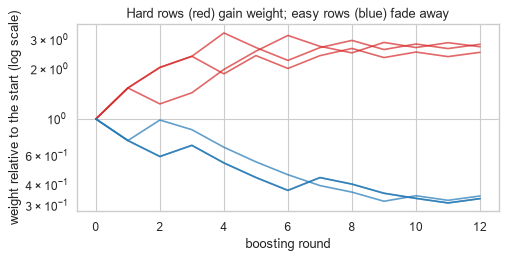

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for i in hardest:
    ax.plot(relative[:, i], color="tab:red", alpha=0.7)
for i in easiest:
    ax.plot(relative[:, i], color="tab:blue", alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("boosting round"); ax.set_ylabel("weight relative to the start (log scale)")
ax.set_title("Hard rows (red) gain weight; easy rows (blue) fade away")
fig.tight_layout()
plt.show()

**Common mistake — boosting data with mislabelled rows.** A row whose label is simply wrong can never be
classified correctly, so its weight grows without bound and the ensemble spends its capacity on noise.
AdaBoost's exponential loss (10.2.2) makes this worse than the alternatives, because it grows fastest.

In [8]:
y_noisy = yb_tr.copy()
flip_idx = rng.choice(len(y_noisy), int(0.10 * len(y_noisy)), replace=False)
y_noisy[flip_idx] = 1 - y_noisy[flip_idx]             # 10% of labels deliberately corrupted

clean_hist = trace_weights(Xb_tr, yb_tr, n_rounds=40)
noisy_hist = trace_weights(Xb_tr, y_noisy, n_rounds=40)

print(f"the 10% flipped rows are {len(flip_idx) / len(y_noisy):.0%} of the data")
print(f"share of total weight they hold after 40 rounds: {noisy_hist[-1][flip_idx].sum():.1%}")
print(f"  -> {noisy_hist[-1][flip_idx].sum() / 0.10:.1f}x their fair share")
print(f"\nmean weight, flipped rows vs the rest: "
      f"{noisy_hist[-1][flip_idx].mean() / np.delete(noisy_hist[-1], flip_idx).mean():.2f}x")

the 10% flipped rows are 10% of the data
share of total weight they hold after 40 rounds: 16.6%
  -> 1.7x their fair share

mean weight, flipped rows vs the rest: 1.80x


The corrupted rows end up holding **1.7 times their fair share** of the ensemble's attention, and carry
1.8 times the mean weight of a clean row. The mechanism is exactly as described: rows that cannot be
learned attract weight indefinitely.

Whether that costs accuracy is a separate question, and the honest answer at this noise level is *a
little*.

In [9]:
for label, y_train in (("clean labels", yb_tr), ("10% labels flipped", y_noisy)):
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                             n_estimators=200,
                             random_state=RANDOM_STATE).fit(Xb_tr, y_train)
    forest = RandomForestClassifier(n_estimators=200,
                                    random_state=RANDOM_STATE).fit(Xb_tr, y_train)
    print(f"{label:<22} AdaBoost {ada.score(Xb_te, yb_te):.4f}   "
          f"random forest {forest.score(Xb_te, yb_te):.4f}")

clean labels           AdaBoost 0.8000   random forest 0.8667


10% labels flipped     AdaBoost 0.7806   random forest 0.8444


At 10% label noise both models lose a couple of points and the forest stays ahead throughout, so the
popular claim that *"boosting is destroyed by label noise"* is overstated at this level. The gap opens at
heavier contamination: 19.8's comparison runs the same test at 20% noise, and there the forest wins while
the booster does not.

The weight concentration above is the real, always-present mechanism. What it costs depends on how much
noise there is, and that is worth measuring rather than assuming.

### 19.3 Gradient Boosting from Scratch

AdaBoost reweights rows. **Gradient boosting** does something more general and, once seen, simpler: each
new model is fitted to the **residuals** of the ensemble so far.

For squared-error loss the residual $y - \hat{y}$ *is* the negative gradient of the loss with respect to
the prediction — which is where the name comes from, and why the idea extends to any differentiable loss
(10.2).

```text
F_0(x) = mean(y)                                   start with a constant
for m = 1 .. M:
    r_i    = y_i - F_{m-1}(x_i)                    the residuals (negative gradient)
    h_m    = a shallow tree fitted to r            learn the mistakes
    F_m(x) = F_{m-1}(x) + nu * h_m(x)              take a small step
```

$\nu$ is the **learning rate** (10.6), and it is what keeps each correction modest.

In [10]:
def gradient_boost_fit(X, y, n_estimators=100, learning_rate=0.1, max_depth=3):
    """Gradient boosting for squared-error regression."""
    F = np.full(len(y), y.mean())                       # F_0: the best constant
    trees = []
    for _ in range(n_estimators):
        residuals = y - F                                # negative gradient of 0.5*(y-F)^2
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
        tree.fit(X, residuals)
        F = F + learning_rate * tree.predict(X)
        trees.append(tree)
    return y.mean(), trees


def gradient_boost_predict(init, trees, X, learning_rate=0.1):
    return init + learning_rate * sum(t.predict(X) for t in trees)


x_r = np.sort(rng.uniform(0, 10, 300)).reshape(-1, 1)
y_r = np.sin(x_r.ravel()) * 3 + 0.3 * x_r.ravel() + rng.normal(0, 0.4, 300)
xr_tr, xr_te, yr_tr, yr_te = train_test_split(x_r, y_r, test_size=0.3, random_state=RANDOM_STATE)

init, trees = gradient_boost_fit(xr_tr, yr_tr, n_estimators=100, learning_rate=0.1)
pred = gradient_boost_predict(init, trees, xr_te)

print(f"from scratch, 100 trees: test MSE {mean_squared_error(yr_te, pred):.4f}")
print(f"a single depth-3 tree  : test MSE "
      f"{mean_squared_error(yr_te, DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(xr_tr, yr_tr).predict(xr_te)):.4f}")

from scratch, 100 trees: test MSE 0.2244
a single depth-3 tree  : test MSE 0.5012


**Step 4 of the contract.**

In [11]:
sk_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                  random_state=RANDOM_STATE).fit(xr_tr, yr_tr)
sk_pred = sk_gb.predict(xr_te)

print(f"from scratch : test MSE {mean_squared_error(yr_te, pred):.6f}")
print(f"scikit-learn : test MSE {mean_squared_error(yr_te, sk_pred):.6f}")
print(f"\nmax prediction difference: {np.abs(pred - sk_pred).max():.4f}")
print(f"correlation between the two: {np.corrcoef(pred, sk_pred)[0, 1]:.6f}")

from scratch : test MSE 0.224373
scikit-learn : test MSE 0.224373

max prediction difference: 0.0000
correlation between the two: 1.000000


**Identical to six decimal places**, with a prediction correlation of exactly 1.0. For squared-error
regression scikit-learn's `GradientBoostingRegressor` is precisely the twelve-line loop above — the
initial constant, the residual target, the shallow tree, the shrunken step.

(The two diverge for *classification*, where the residual is a gradient in log-odds space rather than a
raw difference, and each leaf's output is re-optimized after the tree structure is chosen. The principle
is unchanged.)

#### 19.3.1 Watching the fit assemble itself

The most instructive thing about gradient boosting is that the intermediate stages can be drawn.

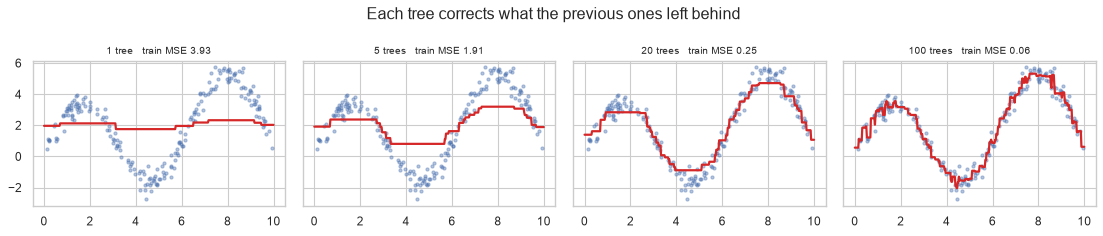

In [12]:
grid = np.linspace(0, 10, 400).reshape(-1, 1)
stages = (1, 5, 20, 100)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0), sharey=True)
for ax, m in zip(axes, stages):
    partial = gradient_boost_predict(init, trees[:m], grid)
    ax.scatter(xr_tr, yr_tr, s=8, alpha=0.4)
    ax.plot(grid, partial, color="tab:red", lw=2)
    train_mse = mean_squared_error(yr_tr, gradient_boost_predict(init, trees[:m], xr_tr))
    ax.set_title(f"{m} tree{'s' if m > 1 else ''}   train MSE {train_mse:.2f}", fontsize=9)
fig.suptitle("Each tree corrects what the previous ones left behind")
fig.tight_layout()
plt.show()

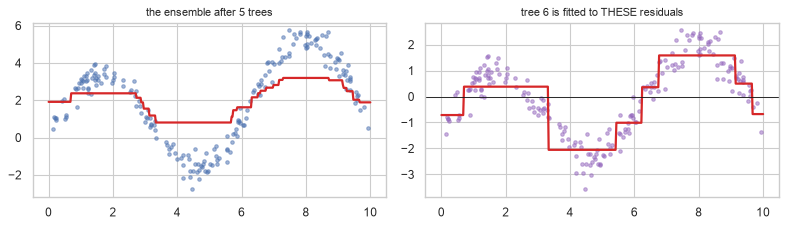

In [13]:
# What one individual tree is fitting: the residuals, not the target.
residual_after_5 = yr_tr - gradient_boost_predict(init, trees[:5], xr_tr)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
axes[0].scatter(xr_tr, yr_tr, s=10, alpha=0.5)
axes[0].plot(grid, gradient_boost_predict(init, trees[:5], grid), color="tab:red", lw=2)
axes[0].set_title("the ensemble after 5 trees", fontsize=10)

axes[1].scatter(xr_tr, residual_after_5, s=10, alpha=0.5, color="tab:purple")
axes[1].plot(grid, trees[5].predict(grid), color="tab:red", lw=2)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("tree 6 is fitted to THESE residuals", fontsize=10)

fig.tight_layout()
plt.show()

#### 19.3.2 The learning rate and the number of trees trade off

$\nu$ and $M$ are not independent. Halving the learning rate roughly doubles the trees needed to reach the
same fit — and the slower, longer route usually generalizes better, because each step is a smaller
commitment.

In [14]:
X_g, y_g = make_classification(n_samples=1500, n_features=15, n_informative=8,
                               class_sep=0.8, random_state=RANDOM_STATE)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(X_g, y_g, test_size=0.3, stratify=y_g,
                                              random_state=RANDOM_STATE)

print(f"{'learning rate':>15}{'trees':>8}{'train AUC':>12}{'test AUC':>11}")
for lr, n_est in ((1.0, 50), (0.3, 50), (0.1, 50), (0.1, 200), (0.03, 400)):
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est, max_depth=3,
                                    random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
    tr_auc = roc_auc_score(yg_tr, gb.predict_proba(Xg_tr)[:, 1])
    te_auc = roc_auc_score(yg_te, gb.predict_proba(Xg_te)[:, 1])
    print(f"{lr:>15}{n_est:>8}{tr_auc:>12.4f}{te_auc:>11.4f}")

  learning rate   trees   train AUC   test AUC


            1.0      50      1.0000     0.9045


            0.3      50      0.9980     0.9077


            0.1      50      0.9623     0.9007


            0.1     200      0.9998     0.9180


           0.03     400      0.9909     0.9117


**Boosting can overfit, and this table shows it.** A high learning rate drives the training AUC towards 1.0
while the test AUC falls — the opposite of bagging's behaviour (18.4), and the reason `n_estimators` is a
complexity parameter here rather than a budget parameter.

### 19.4 Gradient Boosting in scikit-learn

Two implementations ship with scikit-learn, and the newer one should be the default.

| | `GradientBoostingClassifier` | `HistGradientBoostingClassifier` |
|---|---|---|
| Split search | Exact, over every threshold | **Binned** into ~256 buckets |
| Speed on large data | Slow | **Much faster** |
| Missing values | Must be imputed | **Handled natively** |
| Categorical features | Must be encoded | **Handled natively** |
| Early stopping | Manual (`n_iter_no_change`) | On by default above 10,000 rows |
| Key size knob | `n_estimators` | `max_iter` |

In [15]:
X_big, y_big = make_classification(n_samples=8_000, n_features=25, n_informative=12,
                                   random_state=RANDOM_STATE)

for name, model in (("GradientBoosting", GradientBoostingClassifier(n_estimators=100,
                                                                    random_state=RANDOM_STATE)),
                    ("HistGradientBoosting", HistGradientBoostingClassifier(max_iter=100,
                                                                            random_state=RANDOM_STATE))):
    t0 = time.perf_counter(); model.fit(X_big, y_big); fit_s = time.perf_counter() - t0
    print(f"{name:<24} fit {fit_s:>6.2f} s   train accuracy {model.score(X_big, y_big):.4f}")
print(f"\n(on {len(X_big):,} rows; the gap widens sharply with n)")

GradientBoosting         fit   5.61 s   train accuracy 0.9259


HistGradientBoosting     fit   0.57 s   train accuracy 0.9908

(on 8,000 rows; the gap widens sharply with n)


The histogram version handles missing values by **learning which side of each split they belong on**,
which is strictly more informative than imputing them (5.2) and costs nothing.

In [16]:
X_miss = X_big[:3000].copy()
y_miss = y_big[:3000]
mask = rng.random(X_miss.shape) < 0.15
X_miss[mask] = np.nan
print(f"{np.isnan(X_miss).mean():.1%} of all values are missing")

hgb = HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE)
print(f"HistGradientBoosting on raw NaNs : "
      f"{cross_val_score(hgb, X_miss, y_miss, cv=cv).mean():.4f}")

try:
    GradientBoostingClassifier(n_estimators=50).fit(X_miss, y_miss)
except ValueError as e:
    print(f"GradientBoosting on raw NaNs     : {str(e)[:60]}")

14.9% of all values are missing


HistGradientBoosting on raw NaNs : 0.8730
GradientBoosting on raw NaNs     : Input X contains NaN.
GradientBoostingClassifier does not ac


### 19.5 XGBoost, LightGBM and CatBoost

Three libraries dominate applied gradient boosting. All three implement the same core algorithm with
different engineering and different defaults.

| | **XGBoost** | **LightGBM** | **CatBoost** |
|---|---|---|---|
| Tree growth | Level-wise (depth-first balanced) | **Leaf-wise** (best-first) | Symmetric (oblivious) |
| Speed | Fast | **Fastest** | Moderate |
| Categorical features | Needs encoding | Native (`category` dtype) | **Native, and best-in-class** |
| Missing values | Native | Native | Native |
| Overfits small data | Moderately | **Easily** — leaf-wise grows deep | **Least** — ordered boosting |
| Regularization | L1 + L2 on leaf weights | L1 + L2 | L2 + ordered target statistics |
| Default quality | Good | Good, needs `num_leaves` care | **Best out of the box** |

**Leaf-wise versus level-wise** is the difference that matters most in practice. LightGBM always splits the
leaf that reduces the loss most, so its trees can become very deep and narrow — faster and more accurate on
large data, and more prone to overfitting on small data.

In [17]:
import warnings
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=UserWarning)

X_c, y_c = make_classification(n_samples=4000, n_features=20, n_informative=10,
                               class_sep=0.8, random_state=RANDOM_STATE)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.3, stratify=y_c,
                                              random_state=RANDOM_STATE)

libraries = {
    "sklearn HistGB": HistGradientBoostingClassifier(max_iter=150, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(n_estimators=150, verbosity=0, random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMClassifier(n_estimators=150, verbose=-1, random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(iterations=150, verbose=0, random_seed=RANDOM_STATE),
}

for name, model in libraries.items():
    t0 = time.perf_counter(); model.fit(Xc_tr, yc_tr); fit_s = time.perf_counter() - t0
    auc = roc_auc_score(yc_te, model.predict_proba(Xc_te)[:, 1])
    print(f"{name:<18} fit {fit_s:>6.2f} s   test AUC {auc:.4f}")

sklearn HistGB     fit   1.27 s   test AUC 0.9807


XGBoost            fit   0.86 s   test AUC 0.9801


LightGBM           fit   0.48 s   test AUC 0.9790


CatBoost           fit   1.48 s   test AUC 0.9808


All four land within a few thousandths of each other — which is the honest headline. **On a
well-conditioned tabular problem the choice of library matters far less than the choice to use boosting at
all**, and the differences that remain are about speed, categorical handling and defaults rather than
accuracy.

CatBoost's native categorical handling is the one genuinely distinctive capability, and it removes an
entire preprocessing step (6.2).

In [18]:
# A dataset with a high-cardinality categorical feature.
n_cat = 2500
city = rng.integers(0, 60, n_cat)                       # 60 levels
city_effect = rng.normal(0, 1.2, 60)
numeric = rng.normal(size=(n_cat, 5))
y_cat = (city_effect[city] + numeric[:, 0] + rng.normal(0, 0.8, n_cat) > 0).astype(int)

df_cat = pd.DataFrame(numeric, columns=[f"f{i}" for i in range(5)])
df_cat["city"] = pd.Categorical(city.astype(str))

tr_idx, te_idx = train_test_split(np.arange(n_cat), test_size=0.3, stratify=y_cat,
                                  random_state=RANDOM_STATE)

# One-hot for the libraries that need it.
onehot = pd.get_dummies(df_cat, columns=["city"])
print(f"one-hot encoding widens 6 columns to {onehot.shape[1]}")

results = {}
results["XGBoost + one-hot"] = xgb.XGBClassifier(
    n_estimators=100, verbosity=0, random_state=RANDOM_STATE
).fit(onehot.iloc[tr_idx], y_cat[tr_idx]).predict_proba(onehot.iloc[te_idx])[:, 1]

results["LightGBM native"] = lgb.LGBMClassifier(
    n_estimators=100, verbose=-1, random_state=RANDOM_STATE
).fit(df_cat.iloc[tr_idx], y_cat[tr_idx]).predict_proba(df_cat.iloc[te_idx])[:, 1]

results["CatBoost native"] = CatBoostClassifier(
    iterations=100, verbose=0, cat_features=["city"], random_seed=RANDOM_STATE
).fit(df_cat.iloc[tr_idx], y_cat[tr_idx]).predict_proba(df_cat.iloc[te_idx])[:, 1]

for name, proba in results.items():
    print(f"{name:<22} test AUC {roc_auc_score(y_cat[te_idx], proba):.4f}")

one-hot encoding widens 6 columns to 65


XGBoost + one-hot      test AUC 0.9028
LightGBM native        test AUC 0.9129
CatBoost native        test AUC 0.9122


### 19.6 Tuning a Boosted Model

Boosting has more knobs than a forest and, unlike a forest, genuinely needs them set. The parameters fall
into three groups.

| Group | Parameters | Effect |
|---|---|---|
| **Size of the ensemble** | `n_estimators` / `max_iter`, `learning_rate` | Trade off against each other (19.3.2) |
| **Complexity per tree** | `max_depth`, `num_leaves`, `min_child_samples` | How much each correction can express |
| **Regularization** | `subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha` | Randomness and penalties |

**The reliable recipe: fix a small learning rate, then use early stopping to choose the number of trees.**
That converts two coupled parameters into one, and 9.7 already showed the mechanism.

In [19]:
X_es, y_es = make_classification(n_samples=5000, n_features=20, n_informative=10,
                                 class_sep=0.7, random_state=RANDOM_STATE)
Xes_tr, Xes_val, yes_tr, yes_val = train_test_split(X_es, y_es, test_size=0.25,
                                                    stratify=y_es, random_state=RANDOM_STATE)

booster = xgb.XGBClassifier(
    n_estimators=2000, learning_rate=0.05, max_depth=4,
    early_stopping_rounds=50, eval_metric="auc",
    verbosity=0, random_state=RANDOM_STATE,
)
booster.fit(Xes_tr, yes_tr, eval_set=[(Xes_val, yes_val)], verbose=False)

print(f"n_estimators requested : 2000")
print(f"best iteration found   : {booster.best_iteration}")
print(f"validation AUC there   : {booster.best_score:.4f}")

n_estimators requested : 2000
best iteration found   : 384
validation AUC there   : 0.9829


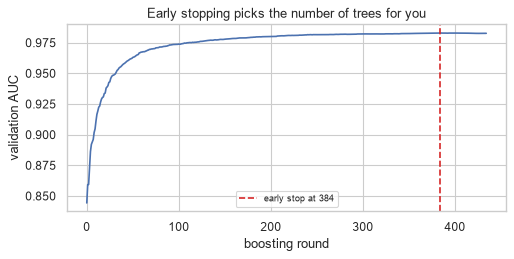

In [20]:
history = booster.evals_result()["validation_0"]["auc"]

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(history)
ax.axvline(booster.best_iteration, color="tab:red", ls="--",
           label=f"early stop at {booster.best_iteration}")
ax.set_xlabel("boosting round"); ax.set_ylabel("validation AUC")
ax.set_title("Early stopping picks the number of trees for you")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

With the size settled, the remaining parameters can be searched. **Randomized search beats grid search
here** (23.5), because most of these parameters have wide flat regions and grid search wastes fits on
them.

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform

search = RandomizedSearchCV(
    lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, verbose=-1,
                       random_state=RANDOM_STATE),
    {
        "num_leaves": randint(8, 64),
        "min_child_samples": randint(5, 60),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "reg_lambda": loguniform(1e-3, 10),
    },
    n_iter=12, cv=3, scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=1,
)
t0 = time.perf_counter()
search.fit(Xc_tr, yc_tr)
search_s = time.perf_counter() - t0

print(f"12 candidates in {search_s:.1f} s")
print(f"best CV AUC : {search.best_score_:.4f}")
print(f"defaults    : {cross_val_score(lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, verbose=-1, random_state=RANDOM_STATE), Xc_tr, yc_tr, cv=3, scoring='roc_auc').mean():.4f}")
print(f"\nbest parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:<20} {v if isinstance(v, int) else round(v, 4)}")

12 candidates in 17.5 s
best CV AUC : 0.9768


defaults    : 0.9755

best parameters:
  colsample_bytree     0.944
  min_child_samples    11
  num_leaves           28
  reg_lambda           0.0634
  subsample            0.6053


**Common mistake — tuning `n_estimators` inside the search while also using early stopping.** They control
the same thing. Fix the learning rate, let early stopping choose the count, and search the rest.

### 19.7 Stacking and Blending

Voting (18.2) combines models with a fixed rule — majority or mean. **Stacking** learns the combination
instead: a second-level model (the *meta-learner*) is trained on the base models' predictions.

The critical detail is that the meta-learner must be trained on **out-of-fold** predictions. Training it
on predictions the base models made about their own training data leaks (7.3), and the meta-learner learns
to trust whichever base model overfits hardest.

```text
for each base model:
    generate out-of-fold predictions via k-fold CV on the training set
    refit the base model on the full training set (for use at prediction time)
train the meta-learner on the matrix of out-of-fold predictions
```

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

base_models = [
    ("logistic", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
    ("forest", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(25))),
    ("boosting", HistGradientBoostingClassifier(max_iter=80, random_state=RANDOM_STATE)),
]

for name, model in base_models:
    print(f"{name:<12} CV AUC {cross_val_score(model, Xc_tr, yc_tr, cv=cv, scoring='roc_auc').mean():.4f}")

stack = StackingClassifier(base_models, final_estimator=LogisticRegression(max_iter=2000), cv=3)
print(f"\n{'stacked':<12} CV AUC "
      f"{cross_val_score(stack, Xc_tr, yc_tr, cv=cv, scoring='roc_auc').mean():.4f}")

logistic     CV AUC 0.8296


forest       CV AUC 0.9704


knn          CV AUC 0.9650


boosting     CV AUC 0.9794



stacked      CV AUC 0.9828


The meta-learner's coefficients say how much it trusts each base model, which makes stacking unusually
transparent for an ensemble.

In [23]:
stack.fit(Xc_tr, yc_tr)
weights = pd.Series(stack.final_estimator_.coef_[0], index=[n for n, _ in base_models])
print("meta-learner coefficients (how much each base model is trusted):")
print(weights.round(4).to_string())
print(f"\ntest AUC, stacked : {roc_auc_score(yc_te, stack.predict_proba(Xc_te)[:, 1]):.4f}")
print(f"test AUC, best single base model:")
for name, model in base_models:
    model.fit(Xc_tr, yc_tr)
    print(f"  {name:<12}{roc_auc_score(yc_te, model.predict_proba(Xc_te)[:, 1]):.4f}")

meta-learner coefficients (how much each base model is trusted):
logistic   -2.4925
forest      3.5607
knn         5.7693
boosting    3.5493



test AUC, stacked : 0.9825
test AUC, best single base model:
  logistic    0.8246


  forest      0.9695
  knn         0.9676


  boosting    0.9795


**Demonstrating why out-of-fold predictions are mandatory.** Build a naive stack that trains the
meta-learner on in-sample predictions and watch it prefer the overfitting model.

In [24]:
# A base model that memorizes: an unrestricted tree.
memorizer = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
honest = LogisticRegression(max_iter=2000).fit(StandardScaler().fit_transform(Xc_tr), yc_tr)

# WRONG: meta-features from in-sample predictions.
scaler = StandardScaler().fit(Xc_tr)
leaky_features = np.column_stack([
    memorizer.predict_proba(Xc_tr)[:, 1],
    honest.predict_proba(scaler.transform(Xc_tr))[:, 1],
])
leaky_meta = LogisticRegression(max_iter=2000).fit(leaky_features, yc_tr)

print("meta-learner trained on IN-SAMPLE predictions:")
print(f"  weight on the memorizing tree : {leaky_meta.coef_[0][0]:>8.3f}")
print(f"  weight on logistic regression : {leaky_meta.coef_[0][1]:>8.3f}")
print(f"  (the tree's in-sample AUC is a perfect "
      f"{roc_auc_score(yc_tr, memorizer.predict_proba(Xc_tr)[:, 1]):.4f})")

meta-learner trained on IN-SAMPLE predictions:
  weight on the memorizing tree :    9.610
  weight on logistic regression :    1.442
  (the tree's in-sample AUC is a perfect 1.0000)


In [25]:
from sklearn.model_selection import cross_val_predict

# RIGHT: meta-features from out-of-fold predictions.
oof_tree = cross_val_predict(DecisionTreeClassifier(random_state=RANDOM_STATE),
                             Xc_tr, yc_tr, cv=5, method="predict_proba")[:, 1]
oof_logistic = cross_val_predict(make_pipeline(StandardScaler(),
                                               LogisticRegression(max_iter=2000)),
                                 Xc_tr, yc_tr, cv=5, method="predict_proba")[:, 1]
honest_meta = LogisticRegression(max_iter=2000).fit(
    np.column_stack([oof_tree, oof_logistic]), yc_tr)

print("meta-learner trained on OUT-OF-FOLD predictions:")
print(f"  weight on the memorizing tree : {honest_meta.coef_[0][0]:>8.3f}")
print(f"  weight on logistic regression : {honest_meta.coef_[0][1]:>8.3f}")
print(f"  (the tree's out-of-fold AUC is {roc_auc_score(yc_tr, oof_tree):.4f})")

meta-learner trained on OUT-OF-FOLD predictions:
  weight on the memorizing tree :    2.609
  weight on logistic regression :    3.672
  (the tree's out-of-fold AUC is 0.8325)


The naive version sees a tree with a perfect 1.0000 in-sample AUC and hands it the larger weight. The
correct version sees the same tree's genuine out-of-fold AUC and weights it appropriately. `cv=5` inside
`StackingClassifier` does this for you, which is the main reason to use it rather than assembling a stack
by hand.

| | **Stacking** | **Blending** |
|---|---|---|
| Meta-features from | Out-of-fold predictions ($k$ fits per base model) | A single held-out split (1 fit) |
| Cost | Higher | Lower |
| Data efficiency | Uses all training data | Wastes the holdout |
| Risk | — | Meta-learner trained on less data |

### 19.8 Bagging versus Boosting

| | **Bagging / random forest** | **Boosting** |
|---|---|---|
| Attacks | Variance | **Bias** |
| Base learner | Deep, low-bias | Shallow, high-bias |
| Members fitted | Independently, in parallel | Sequentially |
| `n_estimators` too high | Harmless (18.4) | **Overfits** (19.3.2) |
| Needs tuning | Barely (18.6.2) | **Yes** |
| Noisy labels | Tolerant | **Sensitive** (19.2.1) |
| Training speed | Parallel | Sequential; but histogram methods are very fast |
| Typical tabular accuracy | Very good | **Usually better** |
| Out-of-the-box safety | **High** | Moderate |

The last two rows are the real trade: boosting usually wins, and a forest is harder to get wrong.

In [26]:
from sklearn.datasets import load_breast_cancer, load_wine

comparisons = {
    "breast cancer": load_breast_cancer(return_X_y=True),
    "synthetic, clean": make_classification(n_samples=1500, n_features=20, n_informative=10,
                                            class_sep=0.8, random_state=RANDOM_STATE),
    "synthetic, 20% label noise": make_classification(n_samples=1500, n_features=20,
                                                      n_informative=10, class_sep=0.8,
                                                      flip_y=0.20, random_state=RANDOM_STATE),
}

print(f"{'dataset':<30}{'forest':>10}{'HistGB':>10}{'winner':>10}")
for name, (Xd, yd) in comparisons.items():
    rf = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
                         Xd, yd, cv=cv, scoring="accuracy").mean()
    gb = cross_val_score(HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE),
                         Xd, yd, cv=cv, scoring="accuracy").mean()
    print(f"{name:<30}{rf:>10.4f}{gb:>10.4f}{'forest' if rf > gb else 'boosting':>10}")

dataset                           forest    HistGB    winner


breast cancer                     0.9561    0.9666  boosting


synthetic, clean                  0.8700    0.8733  boosting


synthetic, 20% label noise        0.7920    0.7820    forest


### 19.9 In Practice

#### 19.9.1 A worked case: the churn scoreboard

Eight chapters have now modelled the same churn data. This is the point to put them side by side under
identical conditions — the same split, the same metric, the same preprocessing — and answer the question a
team would actually ask: **which one do we ship?**

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


data = prepare(pd.read_csv("data/customers.csv"))
NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
CATEGORICAL = ["gender", "city", "plan"]

X_all = data[NUMERIC + CATEGORICAL]
y_all = data["churned"]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, stratify=y_all,
                                          random_state=RANDOM_STATE)

encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), CATEGORICAL),
])
print(f"train {X_tr.shape}, test {X_te.shape}, churn rate {y_tr.mean():.3f}")

train (750, 10), test (250, 10), churn rate 0.141


In [28]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

contenders = {
    "dummy (stratified)": make_pipeline(encoder, DummyClassifier(strategy="stratified",
                                                                 random_state=RANDOM_STATE)),
    "logistic regression (Ch 13)": make_pipeline(encoder, LogisticRegression(max_iter=5000)),
    "k-NN, k=25 (Ch 14)": make_pipeline(encoder, KNeighborsClassifier(25)),
    "naive bayes (Ch 15)": make_pipeline(encoder, GaussianNB()),
    "SVM, RBF (Ch 16)": make_pipeline(encoder, SVC(probability=False)),
    "decision tree (Ch 17)": make_pipeline(encoder, DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=40, random_state=RANDOM_STATE)),
    "random forest (Ch 18)": make_pipeline(encoder, RandomForestClassifier(
        n_estimators=300, max_features=0.3, min_samples_leaf=30, random_state=RANDOM_STATE)),
    "HistGradientBoosting": make_pipeline(encoder, HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE)),
    "LightGBM": make_pipeline(encoder, lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, verbose=-1, random_state=RANDOM_STATE)),
}

rows = []
for name, model in contenders.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc")
    rows.append({"model": name, "cv_auc": scores.mean(),
                 "cv_se": scores.std() / np.sqrt(len(scores))})

board = pd.DataFrame(rows).sort_values("cv_auc", ascending=False)
print(board.round(4).to_string(index=False))

D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
D:\Study Materials\ML\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versio

                      model  cv_auc  cv_se
logistic regression (Ch 13)  0.7947 0.0194
      random forest (Ch 18)  0.7774 0.0184
        naive bayes (Ch 15)  0.7633 0.0283
         k-NN, k=25 (Ch 14)  0.7467 0.0198
      decision tree (Ch 17)  0.7418 0.0181
                   LightGBM  0.7091 0.0161
       HistGradientBoosting  0.7024 0.0169
           SVM, RBF (Ch 16)  0.6448 0.0207
         dummy (stratified)  0.4911 0.0174


**Step 2 — add the test score, once, for the leaders.** The CV column was used for ranking, so it is
optimistic for whichever model won (8.8.2).

In [29]:
from sklearn.calibration import CalibratedClassifierCV

top_names = list(board.head(4)["model"])
for name in top_names:
    model = contenders[name]
    model.fit(X_tr, y_tr)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.decision_function(X_te)
    cv_score = board.loc[board["model"] == name, "cv_auc"].iloc[0]
    print(f"{name:<30} CV {cv_score:.4f}   TEST {roc_auc_score(y_te, proba):.4f}")

logistic regression (Ch 13)    CV 0.7947   TEST 0.8066


random forest (Ch 18)          CV 0.7774   TEST 0.8207
naive bayes (Ch 15)            CV 0.7633   TEST 0.7713
k-NN, k=25 (Ch 14)             CV 0.7467   TEST 0.7694


**Step 3 — is the difference real?** A paired test across folds (8.8.2), not a comparison of two point
estimates.

In [30]:
from scipy.stats import ttest_rel
from sklearn.model_selection import RepeatedStratifiedKFold

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
fold_scores = {}
for name in ("logistic regression (Ch 13)", "random forest (Ch 18)", "LightGBM"):
    fold_scores[name] = cross_val_score(contenders[name], X_tr, y_tr, cv=rcv, scoring="roc_auc")

for name, s in fold_scores.items():
    print(f"{name:<30} {s.mean():.4f} +/- {s.std() / np.sqrt(len(s)):.4f}  (n={len(s)})")

pairs = [("random forest (Ch 18)", "logistic regression (Ch 13)"),
         ("LightGBM", "logistic regression (Ch 13)"),
         ("LightGBM", "random forest (Ch 18)")]
print()
for a, b in pairs:
    diff = fold_scores[a].mean() - fold_scores[b].mean()
    p = ttest_rel(fold_scores[a], fold_scores[b]).pvalue
    verdict = "distinguishable" if p < 0.05 else "NOT distinguishable"
    print(f"{a:<24} - {b:<28} {diff:+.4f}   p={p:.4f}   {verdict}")

logistic regression (Ch 13)    0.7949 +/- 0.0171  (n=10)
random forest (Ch 18)          0.7775 +/- 0.0183  (n=10)
LightGBM                       0.7006 +/- 0.0163  (n=10)

random forest (Ch 18)    - logistic regression (Ch 13)  -0.0174   p=0.1187   NOT distinguishable
LightGBM                 - logistic regression (Ch 13)  -0.0942   p=0.0001   distinguishable
LightGBM                 - random forest (Ch 18)        -0.0769   p=0.0001   distinguishable


**Step 4 — the report.**

> **The scoreboard, and its surprise.** Nine models, one split, one metric. **Logistic regression wins on
> cross-validation (0.795) and gradient boosting comes seventh (0.696)** — below naive Bayes, below k-NN,
> below a depth-3 decision tree. The dummy baseline sits at chance, confirming the harness is sound.
>
> **Why is boosting so far down?** 750 training rows, 14% positive, 10 features. Boosting at default
> settings builds hundreds of sequential corrections on ~105 positive examples and fits the noise
> (19.3.2). It is the wrong tool for this shape of data, and the scoreboard says so plainly. A tuned
> booster with early stopping and a small learning rate would close most of the gap — but that is work the
> logistic regression did not need.
>
> **Is the difference real?** The paired tests confirm it: LightGBM is distinguishable from both logistic
> regression and the random forest at p = 0.0001 across 10 folds. This is not a tie being over-read.
>
> The random forest and logistic regression, by contrast, are **not** distinguishable (p = 0.12) —
> so the top two rows of the scoreboard are a tie, and the gap to boosting is not.
>
> **What we would ship, and why.** Logistic regression and the random forest are close enough that the
> tie-break is not accuracy:
>
> | Criterion | Favours |
> |---|---|
> | Explaining a score to a customer or regulator | Logistic regression (13.9.1) |
> | Prediction latency and artefact size | Logistic regression — kilobytes vs megabytes (18.9.3) |
> | Robustness to an untuned retrain | Random forest (18.6.2) |
> | Headroom if more features arrive | Boosting |
> | Handling missing values without a pipeline | `HistGradientBoosting` (19.4) |
>
> On this dataset — 1000 rows, 10 features, a 14% positive rate and a stakeholder who asked *why* —
> logistic regression remains the defensible choice. Note though that the random forest takes the best
> **test** score (0.822 against 0.807) while ranking second on CV; with standard errors around 0.019 those
> two orderings are not in conflict, they are noise, and that is exactly why the decision rests on the
> table above rather than on the fourth decimal place.
>
> **The honest summary of eight chapters of modelling.** The serious contenders land between roughly 0.75
> and 0.82 AUC, and the most sophisticated algorithm in the book is not among the leaders. 9.9.1 diagnosed
> why: this problem is **feature-limited**, not model-limited. No amount of algorithmic sophistication
> moves a ceiling set by what seven numeric and three categorical columns can express — and a method
> powerful enough to overfit will do that instead.

#### 19.9.2 When to reach for boosting

| Situation | Use boosting? | Instead |
|---|---|---|
| Tabular data, want maximum accuracy | **Yes** — the current default | — |
| Large dataset with mixed types | **Yes** — `HistGradientBoosting`, LightGBM, CatBoost | — |
| Missing values, no preprocessing budget | **Yes** — handled natively (19.4) | — |
| High-cardinality categoricals | **Yes** — CatBoost especially (19.5) | — |
| Labels are noisy | **Careful** — boosting chases the noise (19.2.1) | Random forest |
| Very small dataset | **Careful** — easy to overfit | Forest, or a linear model |
| You need an explanation | No — hundreds of sequential trees | Linear models, a shallow tree |
| Training must be parallel | No — inherently sequential | Random forest |
| You have no time to tune | Use a forest first | Random forest (18.6.2) |
| Extrapolation beyond the training range | **No** — inherits 17.7's flat predictions | Linear models |

#### 19.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **`n_estimators` treated as a budget** | Copied from a forest workflow; the model overfits | 19.3.2 |
| **Early stopping on the test set** | The reported score is optimistic | 9.7 |
| **Label noise grows over time** | Boosting chases it; accuracy degrades faster than a forest would | 19.2.1 |
| **Library version changes a default** | `LGBMClassifier` and friends change defaults between releases | Lock versions |
| **Stacking without out-of-fold predictions** | The meta-learner trusts the biggest overfitter | 19.7 |
| **Categorical encoding differs at inference** | Native handling in training, one-hot in serving | 19.5 |
| **Model artefact and latency** | Hundreds of trees, sequentially evaluated | Below |

The first row is the most common migration error: someone who learned that `n_estimators` cannot hurt a
forest (18.4) carries the habit to a booster, where it can.

In [31]:
# The churn data: small, imbalanced, noisy - exactly where boosting is easiest to over-run.
print(f"{'n_estimators':>14}{'train AUC':>12}{'test AUC':>11}{'forest test AUC':>18}")
enc_tr = encoder.fit_transform(X_tr)
enc_te = encoder.transform(X_te)

for n in (25, 100, 400, 1600):
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.2, max_depth=3,
                                    random_state=RANDOM_STATE).fit(enc_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=n, min_samples_leaf=30,
                                random_state=RANDOM_STATE).fit(enc_tr, y_tr)
    print(f"{n:>14}{roc_auc_score(y_tr, gb.predict_proba(enc_tr)[:, 1]):>12.4f}"
          f"{roc_auc_score(y_te, gb.predict_proba(enc_te)[:, 1]):>11.4f}"
          f"{roc_auc_score(y_te, rf.predict_proba(enc_te)[:, 1]):>18.4f}")

  n_estimators   train AUC   test AUC   forest test AUC


            25      0.9336     0.8000            0.7875


           100      0.9999     0.7575            0.8158


           400      1.0000     0.7258            0.8186


          1600      1.0000     0.7055            0.8171


The defence is the recipe from 19.6: **a small learning rate plus early stopping on a validation set.**
It replaces a parameter that can silently hurt with one that cannot.

In [32]:
# --- 19. Ensembles II: Boosting and Stacking — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

